# Notebook 163: BERTの事前学習 — MLMとNSPを実装する

## Training BERT from Scratch: Masked Language Modeling & Next Sentence Prediction

---

### このノートブックの位置づけ

**言語モデルシリーズ** として、BERTの **事前学習（Pre-training）** を  
ゼロから実装します。Notebook 152（文脈埋め込み）ではBERTの推論と分析を行いましたが、  
本ノートブックでは **BERTがどのように訓練されるか** に焦点を当てます。

難易度: ★★★★☆ | 所要時間: 120-150分 | カテゴリ: 言語モデル

### 前提知識

- ✅ Notebook 152（文脈埋め込み — BERTの推論・分析）
- ✅ Notebook 162（NLP Transformer）
- ✅ PyTorch基礎（Notebook 35-36）

### 学習目標

- [ ] Masked Language Modeling (MLM) の15%マスク戦略（80/10/10ルール）を実装できる
- [ ] Next Sentence Prediction (NSP) の正例/負例ペアを構築できる
- [ ] 小規模コーパスでミニBERTの事前学習ループを実装できる
- [ ] 事前学習済みモデルを分類タスクにファインチューニングできる
- [ ] BERTの学習戦略の設計意図を説明できる
- [ ] 事前学習とファインチューニングの違いを明確に区別できる

### Notebook 152 との違い

| 項目 | Notebook 152 | Notebook 163（本ノート） |
|---|---|---|
| 目的 | BERTの推論・埋め込み分析 | BERTの訓練メカニズム |
| アプローチ | 学習済みモデルを使用 | モデルをゼロから構築・訓練 |
| 焦点 | 層ごとの表現、Attention可視化 | MLM/NSP損失関数、学習ループ |
| 使用モデル | bert-base-uncased（事前学習済み） | ミニBERT（自作、スクラッチ訓練） |

---

## 目次

1. [環境セットアップ](#1-環境セットアップ)
2. [BERTの復習と本ノートブックの位置づけ](#2-bertの復習と本ノートブックの位置づけ)
3. [小規模コーパスの準備](#3-小規模コーパスの準備)
4. [Masked Language Modeling (MLM) の実装](#4-masked-language-modeling-mlm-の実装)
5. [Next Sentence Prediction (NSP) の実装](#5-next-sentence-prediction-nsp-の実装)
6. [ミニBERTモデルの実装](#6-ミニbertモデルの実装)
7. [事前学習ループ](#7-事前学習ループ)
8. [事前学習結果の検証](#8-事前学習結果の検証)
9. [ファインチューニング: テキスト分類](#9-ファインチューニング-テキスト分類)
10. [まとめ・チートシート・よくある間違い・自己評価クイズ](#10-まとめチートシート自己評価クイズ)

---

## 1. 環境セットアップ

In [1]:
# ============================================================
# Section 1: 環境セットアップ
# 必要なライブラリの読み込みと初期設定
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random
import copy
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 再現性のためのシード設定
# ============================================================
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# ============================================================
# 日本語フォント設定（matplotlib用）
# ============================================================
plt.rcParams['font.family'] = ['Hiragino Sans', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ============================================================
# デバイス設定
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("ライブラリの読み込み完了")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"Random seed: 42")

C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


ライブラリの読み込み完了
PyTorch version: 2.1.2+cpu
Device: cpu
Random seed: 42


---

## 2. BERTの復習と本ノートブックの位置づけ

### BERTの2段階学習パラダイム

BERT（Bidirectional Encoder Representations from Transformers）は、  
**2段階の学習パラダイム** を採用しています。

```
【第1段階: 事前学習 (Pre-training)】← 本ノートブックの主題

  大量のテキスト（Wikipedia + BookCorpus）
          ↓
  ┌──────────────────────────────────┐
  │   目的関数1: Masked LM (MLM)    │  入力の15%をマスク → 予測
  │   目的関数2: Next Sentence       │  2文が連続か → 判定
  │              Prediction (NSP)   │
  └──────────────┬───────────────────┘
                 ↓
  汎用的な言語表現を獲得したモデル

【第2段階: ファインチューニング (Fine-tuning)】

  事前学習済みモデル + タスク固有のデータ
          ↓
  ┌──────────────────────────────────┐
  │   分類ヘッドを追加               │  感情分析、NLI、QA 等
  │   全パラメータを微調整            │
  └──────────────────────────────────┘
```

### なぜ事前学習が重要なのか？

1. **大量のラベルなしデータ** から汎用的な言語知識を学習
2. **少量のラベル付きデータ** でタスク固有の性能を獲得
3. **転移学習** の恩恵: 言語の構造・意味を事前に理解

### Notebook 152 → 163 の関係

- **152**: 事前学習**済み**のBERTを使い、埋め込みの性質を分析
- **163（本ノート）**: BERTの事前学習**そのもの**をゼロから実装

本ノートブックでは、小規模なコーパスとミニサイズのBERTを使って、  
事前学習のメカニズムを完全に理解します。

---

## 3. 小規模コーパスの準備

BERTの事前学習を理解するために、小規模な英語コーパスを用意します。  
実際のBERTはWikipedia + BookCorpus（約33億語）で訓練されますが、  
ここでは仕組みの理解に焦点を当てるため、小さなデータセットを使用します。

In [2]:
# ============================================================
# Section 3: 小規模コーパスの準備
# 事前学習用の文ペアデータセットを構築
# ============================================================

# 関連する文ペア（連続する文として扱う）
# 各タプルは (文A, 文B) で、文Bは文Aの続きの文
related_pairs = [
    ("the cat sat on the mat", "it was a warm sunny day"),
    ("the dog ran in the park", "children were playing nearby"),
    ("she went to the store", "she bought some fresh fruit"),
    ("he opened the book", "the story was very interesting"),
    ("the sun rose in the east", "the sky turned bright orange"),
    ("the teacher entered the room", "students sat at their desks"),
    ("rain started to fall", "people opened their umbrellas"),
    ("the bird flew over the tree", "it landed on a branch"),
    ("she cooked dinner at home", "the food smelled delicious"),
    ("he drove to the office", "the traffic was very heavy"),
    ("the baby started crying", "the mother picked it up"),
    ("the train arrived on time", "passengers got on board quickly"),
    ("snow covered the ground", "the children built a snowman"),
    ("the phone rang loudly", "she answered it immediately"),
    ("the flowers bloomed in spring", "the garden looked beautiful"),
    ("he studied hard for the exam", "he passed with a high score"),
    ("the movie started at eight", "the audience enjoyed the show"),
    ("the wind blew strongly", "the leaves fell from the trees"),
    ("she painted a picture", "the colors were bright and vivid"),
    ("the fish swam in the pond", "the water was clear and calm"),
    ("he wrote a long letter", "he sent it to his friend"),
    ("the music played softly", "everyone felt relaxed and happy"),
    ("the boat sailed across the lake", "the sunset was breathtaking"),
    ("she read a book at night", "the lamp provided soft light"),
    ("the chef prepared the meal", "the guests arrived for dinner"),
]

print(f"関連する文ペア数: {len(related_pairs)}")
print(f"例: {related_pairs[0]}")
print(f"例: {related_pairs[5]}")

関連する文ペア数: 25
例: ('the cat sat on the mat', 'it was a warm sunny day')
例: ('the teacher entered the room', 'students sat at their desks')


In [3]:
# ============================================================
# Section 3 (続き): 語彙の構築
# 全文から語彙（Vocabulary）を構築する
# ============================================================

# 特殊トークンの定義
PAD_TOKEN = "[PAD]"   # パディング
UNK_TOKEN = "[UNK]"   # 未知語
CLS_TOKEN = "[CLS]"   # 文頭（分類用）
SEP_TOKEN = "[SEP]"   # 文区切り
MASK_TOKEN = "[MASK]"  # マスクトークン

# 全文からトークン（単語）を収集
all_sentences = []
for sent_a, sent_b in related_pairs:
    all_sentences.append(sent_a)
    all_sentences.append(sent_b)

# 単語レベルのトークナイゼーション（簡易版）
def tokenize(sentence):
    """簡易トークナイザー: 小文字化してスペースで分割"""
    return sentence.lower().split()

# 全単語を収集して頻度をカウント
word_counter = Counter()
for sent in all_sentences:
    tokens = tokenize(sent)
    word_counter.update(tokens)

print(f"ユニーク単語数: {len(word_counter)}")
print(f"総単語数: {sum(word_counter.values())}")
print(f"\n最も頻出する20単語:")
for word, count in word_counter.most_common(20):
    print(f"  {word}: {count}")

ユニーク単語数: 156
総単語数: 250

最も頻出する20単語:
  the: 44
  a: 7
  she: 6
  he: 6
  it: 5
  was: 5
  on: 4
  in: 4
  to: 4
  at: 4
  started: 3
  and: 3
  sat: 2
  children: 2
  were: 2
  opened: 2
  book: 2
  very: 2
  bright: 2
  their: 2


In [4]:
# ============================================================
# Section 3 (続き): 語彙辞書の構築
# 特殊トークン + 全単語 → ID マッピング
# ============================================================

# 特殊トークンを先頭に配置
special_tokens = [PAD_TOKEN, UNK_TOKEN, CLS_TOKEN, SEP_TOKEN, MASK_TOKEN]

# 頻度順にソートした単語リスト
sorted_words = [word for word, _ in word_counter.most_common()]

# 語彙リストの構築
vocab_list = special_tokens + sorted_words
vocab_size = len(vocab_list)

# 単語 → ID、ID → 単語 のマッピング
word2id = {word: idx for idx, word in enumerate(vocab_list)}
id2word = {idx: word for word, idx in word2id.items()}

# 特殊トークンのID
PAD_ID = word2id[PAD_TOKEN]
UNK_ID = word2id[UNK_TOKEN]
CLS_ID = word2id[CLS_TOKEN]
SEP_ID = word2id[SEP_TOKEN]
MASK_ID = word2id[MASK_TOKEN]

print(f"語彙サイズ: {vocab_size}")
print(f"\n特殊トークンのID:")
print(f"  [PAD] = {PAD_ID}")
print(f"  [UNK] = {UNK_ID}")
print(f"  [CLS] = {CLS_ID}")
print(f"  [SEP] = {SEP_ID}")
print(f"  [MASK] = {MASK_ID}")
print(f"\n通常の単語の例:")
for word in sorted_words[:10]:
    print(f"  '{word}' = {word2id[word]}")

語彙サイズ: 161

特殊トークンのID:
  [PAD] = 0
  [UNK] = 1
  [CLS] = 2
  [SEP] = 3
  [MASK] = 4

通常の単語の例:
  'the' = 5
  'a' = 6
  'she' = 7
  'he' = 8
  'it' = 9
  'was' = 10
  'on' = 11
  'in' = 12
  'to' = 13
  'at' = 14


In [5]:
# ============================================================
# Section 3 (続き): 文のトークンID化
# テキスト文をトークンIDの系列に変換
# ============================================================

def encode_sentence(sentence, max_len=None):
    """
    文をトークンIDのリストに変換する。
    
    Parameters:
    -----------
    sentence : str
        入力文
    max_len : int or None
        最大長（Noneの場合はパディングなし）
    
    Returns:
    --------
    list of int : トークンIDのリスト
    """
    tokens = tokenize(sentence)
    ids = [word2id.get(token, UNK_ID) for token in tokens]
    
    if max_len is not None:
        # パディングまたはトランケーション
        if len(ids) < max_len:
            ids = ids + [PAD_ID] * (max_len - len(ids))
        else:
            ids = ids[:max_len]
    
    return ids


def decode_ids(ids):
    """
    トークンIDのリストをテキストに変換する。
    """
    return [id2word.get(id, UNK_TOKEN) for id in ids]


# テスト
test_sent = "the cat sat on the mat"
encoded = encode_sentence(test_sent)
decoded = decode_ids(encoded)

print(f"元の文: '{test_sent}'")
print(f"トークン: {tokenize(test_sent)}")
print(f"エンコード: {encoded}")
print(f"デコード: {decoded}")
print()

# BERT形式の入力を構築する関数
def create_bert_input(sent_a, sent_b, max_seq_len=64):
    """
    2つの文からBERT形式の入力を構築する。
    [CLS] sent_a [SEP] sent_b [SEP] + padding
    
    Returns:
    --------
    input_ids : list of int
    token_type_ids : list of int (0=文A, 1=文B)
    attention_mask : list of int (1=有効, 0=パディング)
    """
    tokens_a = encode_sentence(sent_a)
    tokens_b = encode_sentence(sent_b)
    
    # [CLS] tokens_a [SEP] tokens_b [SEP]
    input_ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
    # Segment IDs: 文Aは0、文Bは1
    token_type_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
    # Attention mask: 全て有効
    attention_mask = [1] * len(input_ids)
    
    # パディング
    pad_len = max_seq_len - len(input_ids)
    if pad_len > 0:
        input_ids += [PAD_ID] * pad_len
        token_type_ids += [0] * pad_len
        attention_mask += [0] * pad_len
    else:
        # トランケーション（必要な場合）
        input_ids = input_ids[:max_seq_len]
        token_type_ids = token_type_ids[:max_seq_len]
        attention_mask = attention_mask[:max_seq_len]
    
    return input_ids, token_type_ids, attention_mask


# テスト
sent_a = "the cat sat on the mat"
sent_b = "it was a warm sunny day"
input_ids, token_type_ids, attention_mask = create_bert_input(sent_a, sent_b, max_seq_len=20)

print("BERT形式の入力:")
print(f"  input_ids:      {input_ids}")
print(f"  token_type_ids: {token_type_ids}")
print(f"  attention_mask: {attention_mask}")
print(f"  デコード:       {decode_ids(input_ids)}")

元の文: 'the cat sat on the mat'
トークン: ['the', 'cat', 'sat', 'on', 'the', 'mat']
エンコード: [5, 28, 17, 11, 5, 29]
デコード: ['the', 'cat', 'sat', 'on', 'the', 'mat']

BERT形式の入力:
  input_ids:      [2, 5, 28, 17, 11, 5, 29, 3, 9, 10, 6, 30, 31, 32, 3, 0, 0, 0, 0, 0]
  token_type_ids: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
  デコード:       ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]', 'it', 'was', 'a', 'warm', 'sunny', 'day', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


---

## 4. Masked Language Modeling (MLM) の実装

### MLMの概要

BERTの第1の事前学習目的関数である **Masked Language Modeling (MLM)** は、  
入力テキストの一部を隠して、その隠された単語を予測するタスクです。

### 15%マスク戦略と80/10/10ルール

```
入力: The cat sat on the mat
                  ↓ 15%をランダムに選択
選ばれたトークン: "sat"
                  ↓ 80/10/10 ルール
  80%の確率 → [MASK] に置換   : The cat [MASK] on the mat
  10%の確率 → ランダムな単語  : The cat dog on the mat  
  10%の確率 → そのまま        : The cat sat on the mat

目標: 元の "sat" を予測する
```

### なぜ80/10/10なのか？

- **80% [MASK]**: モデルに「隠された単語を推測する」能力を学ばせる
- **10% ランダム置換**: [MASK]トークンはファインチューニング時に出現しないため、  
  モデルが[MASK]に依存しすぎないようにする
- **10% そのまま**: モデルに「全ての位置で正しい表現を維持する」ことを促す

この巧妙な設計により、BERTは **全位置のトークンに対する良い表現** を学習します。

In [6]:
# ============================================================
# Section 4: Masked Language Modeling (MLM) の実装
# 15%マスク戦略（80/10/10ルール）
# ============================================================

def apply_mlm_masking(input_ids, attention_mask, vocab_size,
                      mask_prob=0.15, mask_token_id=MASK_ID,
                      special_token_ids=None):
    """
    BERTのMLMマスキングを適用する。
    
    Parameters:
    -----------
    input_ids : list of int
        入力トークンIDの系列
    attention_mask : list of int
        1=有効トークン, 0=パディング
    vocab_size : int
        語彙サイズ（ランダム置換用）
    mask_prob : float
        マスクする確率（デフォルト: 15%）
    mask_token_id : int
        [MASK]トークンのID
    special_token_ids : set of int
        マスクしない特殊トークンのIDセット
    
    Returns:
    --------
    masked_ids : list of int
        マスク適用後のトークンID
    mlm_labels : list of int
        各位置の正解ラベル（マスクされていない位置は-100）
    mask_positions : list of int
        マスクされた位置のインデックス
    """
    if special_token_ids is None:
        special_token_ids = {PAD_ID, CLS_ID, SEP_ID}
    
    masked_ids = list(input_ids)  # コピー
    mlm_labels = [-100] * len(input_ids)  # -100 = 損失計算で無視
    mask_positions = []
    
    # マスク候補のインデックス（特殊トークン以外で有効なトークン）
    candidate_indices = []
    for i, (token_id, mask) in enumerate(zip(input_ids, attention_mask)):
        if mask == 1 and token_id not in special_token_ids:
            candidate_indices.append(i)
    
    # 15%のトークンをランダムに選択
    num_to_mask = max(1, int(len(candidate_indices) * mask_prob))
    selected_indices = random.sample(candidate_indices,
                                     min(num_to_mask, len(candidate_indices)))
    
    for idx in selected_indices:
        # 正解ラベルを設定
        mlm_labels[idx] = input_ids[idx]
        mask_positions.append(idx)
        
        rand_val = random.random()
        if rand_val < 0.8:
            # 80%: [MASK]に置換
            masked_ids[idx] = mask_token_id
        elif rand_val < 0.9:
            # 10%: ランダムな単語に置換
            # 特殊トークンを避ける
            random_token = random.randint(len(special_tokens), vocab_size - 1)
            masked_ids[idx] = random_token
        else:
            # 10%: そのまま（変更しない）
            pass
    
    return masked_ids, mlm_labels, mask_positions


print("MLMマスキング関数を定義しました")
print("\n--- MLMマスキングのデモ ---")
print()

MLMマスキング関数を定義しました

--- MLMマスキングのデモ ---



In [7]:
# ============================================================
# Section 4 (続き): MLMマスキングのデモンストレーション
# 具体的な例でマスクパターンを確認
# ============================================================

# デモ用の文ペア
demo_sent_a = "the cat sat on the mat"
demo_sent_b = "it was a warm sunny day"

input_ids, token_type_ids, attention_mask = create_bert_input(
    demo_sent_a, demo_sent_b, max_seq_len=20
)

print("元の入力:")
print(f"  IDs:    {input_ids}")
print(f"  Tokens: {decode_ids(input_ids)}")
print()

# 5回マスキングを実行して、ランダム性を確認
print("MLMマスキングを5回実行:")
print("-" * 70)

for trial in range(5):
    masked_ids, mlm_labels, mask_positions = apply_mlm_masking(
        input_ids, attention_mask, vocab_size
    )
    
    masked_tokens = decode_ids(masked_ids)
    
    # マスクされた位置を強調表示
    display_tokens = []
    for i, (orig, masked) in enumerate(zip(decode_ids(input_ids), masked_tokens)):
        if mlm_labels[i] != -100:
            display_tokens.append(f"*{masked}*")
        else:
            display_tokens.append(masked)
    
    print(f"  試行{trial+1}: {' '.join(display_tokens[:15])}")
    print(f"         マスク位置: {mask_positions}, 正解: {[id2word[l] for l in mlm_labels if l != -100]}")
    print()

元の入力:
  IDs:    [2, 5, 28, 17, 11, 5, 29, 3, 9, 10, 6, 30, 31, 32, 3, 0, 0, 0, 0, 0]
  Tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '[SEP]', 'it', 'was', 'a', 'warm', 'sunny', 'day', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

MLMマスキングを5回実行:
----------------------------------------------------------------------
  試行1: [CLS] the cat sat on the mat [SEP] it was a warm *[MASK]* day [SEP]
         マスク位置: [12], 正解: ['sunny']

  試行2: [CLS] the cat sat on the mat [SEP] it was a warm sunny *[MASK]* [SEP]
         マスク位置: [13], 正解: ['day']

  試行3: [CLS] the cat sat *[MASK]* the mat [SEP] it was a warm sunny day [SEP]
         マスク位置: [4], 正解: ['on']

  試行4: [CLS] the *[MASK]* sat on the mat [SEP] it was a warm sunny day [SEP]
         マスク位置: [2], 正解: ['cat']

  試行5: [CLS] the cat sat on the mat [SEP] it was *[MASK]* warm sunny day [SEP]
         マスク位置: [10], 正解: ['a']



findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' n

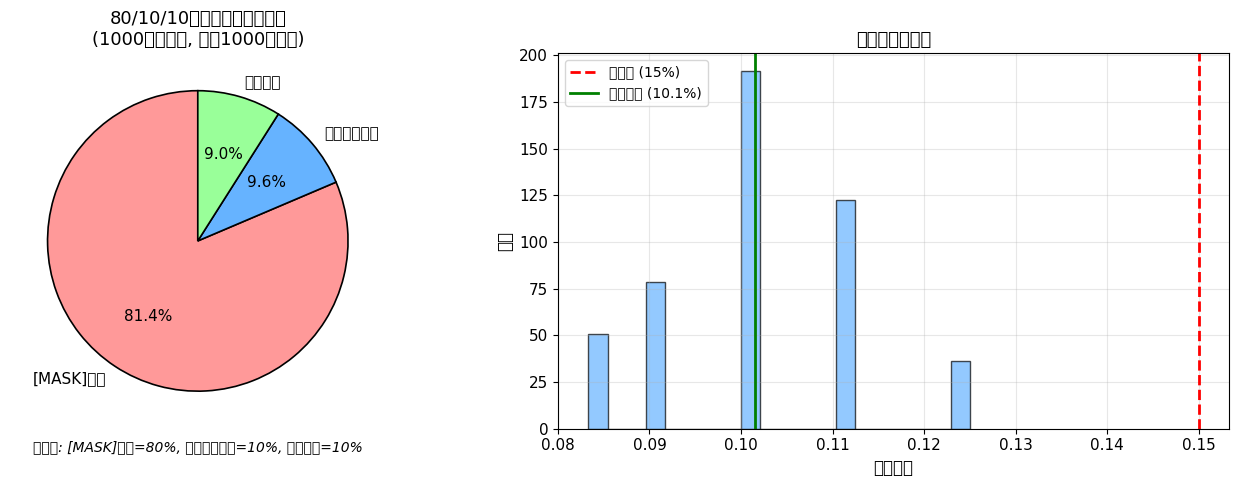

統計結果:
  平均マスク率: 10.1%
  [MASK]置換: 814/1000 = 81.4%
  ランダム置換: 96/1000 = 9.6%
  そのまま: 90/1000 = 9.0%


In [8]:
# ============================================================
# Section 4 (続き): マスクパターンの可視化
# Plot 1: 80/10/10ルールの統計的検証
# ============================================================

# 多数回のマスキングを実行して統計を収集
num_trials = 1000
mask_type_counts = {'[MASK]置換': 0, 'ランダム置換': 0, 'そのまま': 0}
total_masked = 0
mask_ratio_history = []

for _ in range(num_trials):
    # ランダムな文ペアを選択
    sent_a, sent_b = random.choice(related_pairs)
    input_ids_trial, _, attn_mask_trial = create_bert_input(sent_a, sent_b, max_seq_len=20)
    
    masked_ids_trial, mlm_labels_trial, mask_pos_trial = apply_mlm_masking(
        input_ids_trial, attn_mask_trial, vocab_size
    )
    
    # 有効トークン数（特殊トークンとパディングを除く）
    special_ids = {PAD_ID, CLS_ID, SEP_ID}
    valid_count = sum(1 for i, m in zip(input_ids_trial, attn_mask_trial)
                      if m == 1 and i not in special_ids)
    masked_count = len(mask_pos_trial)
    if valid_count > 0:
        mask_ratio_history.append(masked_count / valid_count)
    
    # マスクの種類をカウント
    for pos in mask_pos_trial:
        total_masked += 1
        if masked_ids_trial[pos] == MASK_ID:
            mask_type_counts['[MASK]置換'] += 1
        elif masked_ids_trial[pos] == input_ids_trial[pos]:
            mask_type_counts['そのまま'] += 1
        else:
            mask_type_counts['ランダム置換'] += 1

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左: 80/10/10ルールの実際の分布 ---
labels_pie = list(mask_type_counts.keys())
counts_pie = list(mask_type_counts.values())
percentages = [c / total_masked * 100 for c in counts_pie]
colors_pie = ['#ff9999', '#66b3ff', '#99ff99']

axes[0].pie(percentages, labels=labels_pie, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops=dict(edgecolor='black', linewidth=1.2))
axes[0].set_title(f'80/10/10ルールの実際の分布\n({num_trials}回の試行, 合計{total_masked}マスク)', fontsize=13)

# 理論値との比較を注釈
axes[0].text(0, -1.4, '理論値: [MASK]置換=80%, ランダム置換=10%, そのまま=10%',
            ha='center', fontsize=10, style='italic')

# --- 右: マスク率のヒストグラム ---
axes[1].hist(mask_ratio_history, bins=20, color='#66b3ff',
            edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(x=0.15, color='red', linestyle='--', linewidth=2,
               label='理論値 (15%)')
axes[1].axvline(x=np.mean(mask_ratio_history), color='green', linestyle='-',
               linewidth=2, label=f'実測平均 ({np.mean(mask_ratio_history):.1%})')
axes[1].set_xlabel('マスク率', fontsize=12)
axes[1].set_ylabel('密度', fontsize=12)
axes[1].set_title('マスク率の分布', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"統計結果:")
print(f"  平均マスク率: {np.mean(mask_ratio_history):.1%}")
for label, count in mask_type_counts.items():
    print(f"  {label}: {count}/{total_masked} = {count/total_masked:.1%}")

---

## 5. Next Sentence Prediction (NSP) の実装

### NSPの概要

BERTの第2の事前学習目的関数である **Next Sentence Prediction (NSP)** は、  
2つの文が元のテキストで連続しているかを判定する二値分類タスクです。

```
【正例 (IsNext)】
  文A: "The cat sat on the mat"
  文B: "It was a warm sunny day"  ← 実際に文Aの後に続く文
  ラベル: 1 (IsNext)

【負例 (NotNext)】
  文A: "The cat sat on the mat"
  文B: "He drove to the office"   ← ランダムに選ばれた無関係な文
  ラベル: 0 (NotNext)
```

### NSPの目的

- **文間の関係性** を理解する能力を学習
- QA（質問応答）やNLI（自然言語推論）などの **文ペアタスク** に有効
- [CLS]トークンの出力に文全体の情報を集約させる

> **注意**: 後の研究（RoBERTa等）ではNSPの有効性に疑問が呈されましたが、  
> BERTの設計を理解する上で重要な構成要素です。

In [9]:
# ============================================================
# Section 5: Next Sentence Prediction (NSP) の実装
# 正例/負例ペアの構築
# ============================================================

def create_nsp_data(related_pairs, neg_ratio=0.5):
    """
    NSP用の訓練データを構築する。
    
    Parameters:
    -----------
    related_pairs : list of (str, str)
        関連する文ペアのリスト
    neg_ratio : float
        負例の割合（デフォルト: 50%）
    
    Returns:
    --------
    nsp_data : list of (str, str, int)
        (文A, 文B, ラベル) のリスト
        ラベル: 1=IsNext, 0=NotNext
    """
    nsp_data = []
    all_sents = [s for pair in related_pairs for s in pair]
    
    for sent_a, sent_b in related_pairs:
        # 正例: 実際に連続する文ペア
        nsp_data.append((sent_a, sent_b, 1))  # IsNext
        
        # 負例: ランダムに選んだ文をペアにする
        if random.random() < neg_ratio:
            # sent_bをランダムな文に置換
            random_sent_b = random.choice(all_sents)
            # 元のペアと同じにならないようにする
            while random_sent_b == sent_b:
                random_sent_b = random.choice(all_sents)
            nsp_data.append((sent_a, random_sent_b, 0))  # NotNext
    
    return nsp_data


# NSPデータの生成
nsp_data = create_nsp_data(related_pairs, neg_ratio=1.0)
random.shuffle(nsp_data)

# 統計を表示
num_positive = sum(1 for _, _, label in nsp_data if label == 1)
num_negative = sum(1 for _, _, label in nsp_data if label == 0)

print(f"NSPデータセット:")
print(f"  合計: {len(nsp_data)}")
print(f"  正例 (IsNext):  {num_positive}")
print(f"  負例 (NotNext): {num_negative}")
print()
print("例（正例 IsNext）:")
for sent_a, sent_b, label in nsp_data:
    if label == 1:
        print(f"  A: '{sent_a}'")
        print(f"  B: '{sent_b}'")
        print(f"  Label: {label} (IsNext)")
        break
print()
print("例（負例 NotNext）:")
for sent_a, sent_b, label in nsp_data:
    if label == 0:
        print(f"  A: '{sent_a}'")
        print(f"  B: '{sent_b}'")
        print(f"  Label: {label} (NotNext)")
        break

NSPデータセット:
  合計: 50
  正例 (IsNext):  25
  負例 (NotNext): 25

例（正例 IsNext）:
  A: 'the fish swam in the pond'
  B: 'the water was clear and calm'
  Label: 1 (IsNext)

例（負例 NotNext）:
  A: 'rain started to fall'
  B: 'he passed with a high score'
  Label: 0 (NotNext)


---

## 6. ミニBERTモデルの実装

### モデル構成

実際のBERT-baseは以下の規模ですが、ここでは学習が高速に完了する  
**ミニBERT**を実装します。

| パラメータ | BERT-base | ミニBERT（本実装） |
|---|---|---|
| Transformer層数 | 12 | 4 |
| Attentionヘッド数 | 12 | 4 |
| 隠れ次元数 (d_model) | 768 | 128 |
| FFN中間次元 | 3072 | 512 |
| 語彙サイズ | 30,522 | ~100 |
| パラメータ数 | ~110M | ~1M以下 |

In [10]:
# ============================================================
# Section 6: ミニBERTモデルの実装
# BERTConfig + TransformerEncoderベースの構造
# ============================================================

class BERTConfig:
    """
    ミニBERTの設定クラス。
    学習用の小規模パラメータを定義する。
    """
    def __init__(
        self,
        vocab_size=100,
        d_model=128,        # 隠れ次元数
        n_layers=4,         # Transformer層数
        n_heads=4,          # Attentionヘッド数
        d_ff=512,           # FFN中間次元
        max_seq_len=64,     # 最大系列長
        dropout=0.1,        # Dropout率
    ):
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_ff = d_ff
        self.max_seq_len = max_seq_len
        self.dropout = dropout
        self.d_head = d_model // n_heads  # ヘッドあたりの次元


class BERTEmbedding(nn.Module):
    """
    BERTの入力埋め込み層。
    Token Embedding + Position Embedding + Segment Embedding を合算。
    """
    def __init__(self, config):
        super().__init__()
        # トークン埋め込み: 語彙の各単語をd_model次元に変換
        self.token_embedding = nn.Embedding(config.vocab_size, config.d_model,
                                           padding_idx=PAD_ID)
        # 位置埋め込み: 各位置をd_model次元に変換
        self.position_embedding = nn.Embedding(config.max_seq_len, config.d_model)
        # セグメント埋め込み: 文A(0)と文B(1)を区別
        self.segment_embedding = nn.Embedding(2, config.d_model)
        # Layer Normalization
        self.layer_norm = nn.LayerNorm(config.d_model)
        # Dropout
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, input_ids, token_type_ids):
        """
        Parameters:
        -----------
        input_ids : (batch, seq_len)
        token_type_ids : (batch, seq_len)
        
        Returns:
        --------
        embeddings : (batch, seq_len, d_model)
        """
        seq_len = input_ids.size(1)
        # 位置インデックス: [0, 1, 2, ..., seq_len-1]
        position_ids = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        
        # 3つの埋め込みを合算
        x = (self.token_embedding(input_ids)
             + self.position_embedding(position_ids)
             + self.segment_embedding(token_type_ids))
        
        x = self.layer_norm(x)
        x = self.dropout(x)
        return x


print("BERTConfig, BERTEmbedding クラスを定義しました")

BERTConfig, BERTEmbedding クラスを定義しました


In [11]:
# ============================================================
# Section 6 (続き): Transformer Encoder + MLM/NSPヘッドの実装
# ============================================================

class MiniBERT(nn.Module):
    """
    ミニBERTモデル。
    TransformerEncoderベースの実装に、MLMヘッドとNSPヘッドを追加。
    """
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        # ============================================================
        # 入力埋め込み層
        # ============================================================
        self.embedding = BERTEmbedding(config)
        
        # ============================================================
        # Transformer Encoder
        # PyTorchのTransformerEncoderLayerを使用
        # ============================================================
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model,
            nhead=config.n_heads,
            dim_feedforward=config.d_ff,
            dropout=config.dropout,
            activation='gelu',     # BERTはGELU活性化を使用
            batch_first=True,      # (batch, seq, feature) 形式
            norm_first=False,      # Post-LN (BERTのオリジナル設定)
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.n_layers,
        )
        
        # ============================================================
        # MLMヘッド: マスクされたトークンを予測
        # hidden → d_model → vocab_size
        # ============================================================
        self.mlm_head = nn.Sequential(
            nn.Linear(config.d_model, config.d_model),
            nn.GELU(),
            nn.LayerNorm(config.d_model),
            nn.Linear(config.d_model, config.vocab_size),
        )
        
        # ============================================================
        # NSPヘッド: [CLS]トークンから文ペアの関係を予測
        # hidden → d_model → 2 (IsNext / NotNext)
        # ============================================================
        self.nsp_head = nn.Sequential(
            nn.Linear(config.d_model, config.d_model),
            nn.Tanh(),
            nn.Linear(config.d_model, 2),
        )
    
    def forward(self, input_ids, token_type_ids, attention_mask):
        """
        Parameters:
        -----------
        input_ids : (batch, seq_len)
        token_type_ids : (batch, seq_len)
        attention_mask : (batch, seq_len)
            1=有効トークン, 0=パディング
        
        Returns:
        --------
        mlm_logits : (batch, seq_len, vocab_size)
            各位置での語彙上の確率分布
        nsp_logits : (batch, 2)
            NSP予測（IsNext / NotNext）
        hidden_states : (batch, seq_len, d_model)
            最終層の隠れ状態
        """
        # ============================================================
        # Attention Mask の変換
        # PyTorchのTransformerEncoderはsrc_key_padding_maskを使用
        # True = マスク（無視）、False = 有効
        # ============================================================
        padding_mask = (attention_mask == 0)  # パディング位置をTrue
        
        # 埋め込み
        x = self.embedding(input_ids, token_type_ids)
        
        # Transformer Encoder
        hidden_states = self.encoder(x, src_key_padding_mask=padding_mask)
        
        # MLMヘッド: 全位置の予測
        mlm_logits = self.mlm_head(hidden_states)  # (batch, seq_len, vocab_size)
        
        # NSPヘッド: [CLS]トークン（位置0）の出力を使用
        cls_output = hidden_states[:, 0, :]  # (batch, d_model)
        nsp_logits = self.nsp_head(cls_output)  # (batch, 2)
        
        return mlm_logits, nsp_logits, hidden_states


print("MiniBERT モデルを定義しました")

MiniBERT モデルを定義しました


In [12]:
# ============================================================
# Section 6 (続き): モデルのインスタンス化とパラメータ数の確認
# ============================================================

# 設定
config = BERTConfig(
    vocab_size=vocab_size,
    d_model=128,
    n_layers=4,
    n_heads=4,
    d_ff=512,
    max_seq_len=64,
    dropout=0.1,
)

# モデルのインスタンス化
model = MiniBERT(config).to(device)

# パラメータ数の詳細
print("=" * 70)
print("ミニBERTモデルの構成")
print("=" * 70)
print()
print(f"  語彙サイズ:         {config.vocab_size}")
print(f"  隠れ次元数:         {config.d_model}")
print(f"  Transformer層数:    {config.n_layers}")
print(f"  Attentionヘッド数:  {config.n_heads}")
print(f"  ヘッドあたりの次元: {config.d_head}")
print(f"  FFN中間次元:        {config.d_ff}")
print(f"  最大系列長:         {config.max_seq_len}")
print(f"  Dropout率:          {config.dropout}")
print()

# 各モジュールのパラメータ数を表示
total_params = 0
print("パラメータ数の内訳:")
print("-" * 50)
for name, param in model.named_parameters():
    if param.requires_grad:
        num = param.numel()
        total_params += num
        # モジュール名を短縮して表示
        short_name = name[:45]
        print(f"  {short_name:<45} {num:>8,}")

print("-" * 50)
print(f"  {'合計パラメータ数':<45} {total_params:>8,}")
print()
print(f"BERT-base (110M) の約 {total_params/110_000_000:.4%} のサイズです")

ミニBERTモデルの構成

  語彙サイズ:         161
  隠れ次元数:         128
  Transformer層数:    4
  Attentionヘッド数:  4
  ヘッドあたりの次元: 32
  FFN中間次元:        512
  最大系列長:         64
  Dropout率:          0.1

パラメータ数の内訳:
--------------------------------------------------
  embedding.token_embedding.weight                20,608
  embedding.position_embedding.weight              8,192
  embedding.segment_embedding.weight                 256
  embedding.layer_norm.weight                        128
  embedding.layer_norm.bias                          128
  encoder.layers.0.self_attn.in_proj_weight       49,152
  encoder.layers.0.self_attn.in_proj_bias            384
  encoder.layers.0.self_attn.out_proj.weight      16,384
  encoder.layers.0.self_attn.out_proj.bias           128
  encoder.layers.0.linear1.weight                 65,536
  encoder.layers.0.linear1.bias                      512
  encoder.layers.0.linear2.weight                 65,536
  encoder.layers.0.linear2.bias                      128
  encoder.layer

---

## 7. 事前学習ループ

### 訓練の概要

事前学習では、**MLM損失** と **NSP損失** を **同時に** 最適化します。

```
合計損失 = MLM損失 + NSP損失

MLM損失: マスクされた位置でのクロスエントロピー損失
NSP損失: [CLS]トークンでの二値分類クロスエントロピー損失
```

In [13]:
# ============================================================
# Section 7: 事前学習用データセットクラス
# MLM + NSP の両方のデータを生成する
# ============================================================

class BERTPretrainDataset(Dataset):
    """
    BERT事前学習用のデータセット。
    各サンプルについて、MLMマスキングとNSPラベルを生成する。
    """
    def __init__(self, nsp_data, word2id, vocab_size, max_seq_len=64):
        self.nsp_data = nsp_data
        self.word2id = word2id
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
    
    def __len__(self):
        return len(self.nsp_data)
    
    def __getitem__(self, idx):
        sent_a, sent_b, nsp_label = self.nsp_data[idx]
        
        # BERT形式の入力を構築
        input_ids, token_type_ids, attention_mask = create_bert_input(
            sent_a, sent_b, self.max_seq_len
        )
        
        # MLMマスキングを適用
        masked_ids, mlm_labels, _ = apply_mlm_masking(
            input_ids, attention_mask, self.vocab_size
        )
        
        return {
            'input_ids': torch.tensor(masked_ids, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'mlm_labels': torch.tensor(mlm_labels, dtype=torch.long),
            'nsp_label': torch.tensor(nsp_label, dtype=torch.long),
            # 元のIDも保持（検証用）
            'original_ids': torch.tensor(input_ids, dtype=torch.long),
        }


# データセットとDataLoaderの作成
max_seq_len = 32

train_dataset = BERTPretrainDataset(
    nsp_data, word2id, vocab_size, max_seq_len=max_seq_len
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    drop_last=False,
)

print(f"データセットサイズ: {len(train_dataset)}")
print(f"バッチサイズ: 8")
print(f"バッチ数: {len(train_loader)}")
print(f"最大系列長: {max_seq_len}")

# サンプルバッチの確認
sample_batch = next(iter(train_loader))
print(f"\nサンプルバッチの形状:")
for key, value in sample_batch.items():
    print(f"  {key}: {value.shape}")

データセットサイズ: 50
バッチサイズ: 8
バッチ数: 7
最大系列長: 32

サンプルバッチの形状:
  input_ids: torch.Size([8, 32])
  token_type_ids: torch.Size([8, 32])
  attention_mask: torch.Size([8, 32])
  mlm_labels: torch.Size([8, 32])
  nsp_label: torch.Size([8])
  original_ids: torch.Size([8, 32])


In [14]:
# ============================================================
# Section 7 (続き): 事前学習ループの実装
# MLM損失 + NSP損失 を同時に最適化
# ============================================================

# 最適化設定
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# 損失関数
mlm_criterion = nn.CrossEntropyLoss(ignore_index=-100)  # -100は無視
nsp_criterion = nn.CrossEntropyLoss()

# 学習記録
num_epochs = 80
history = {
    'total_loss': [],
    'mlm_loss': [],
    'nsp_loss': [],
    'mlm_accuracy': [],
    'nsp_accuracy': [],
}

print("=" * 70)
print("事前学習を開始します")
print("=" * 70)
print(f"  エポック数: {num_epochs}")
print(f"  学習率: 1e-3")
print(f"  最適化: AdamW (weight_decay=0.01)")
print()

model.train()

for epoch in range(num_epochs):
    epoch_total_loss = 0.0
    epoch_mlm_loss = 0.0
    epoch_nsp_loss = 0.0
    epoch_mlm_correct = 0
    epoch_mlm_total = 0
    epoch_nsp_correct = 0
    epoch_nsp_total = 0
    
    for batch in train_loader:
        # データをデバイスに転送
        input_ids = batch['input_ids'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        mlm_labels = batch['mlm_labels'].to(device)
        nsp_labels = batch['nsp_label'].to(device)
        
        # 順伝播
        mlm_logits, nsp_logits, _ = model(input_ids, token_type_ids, attention_mask)
        
        # ============================================================
        # MLM損失の計算
        # mlm_logits: (batch, seq_len, vocab_size)
        # mlm_labels: (batch, seq_len) - マスクされていない位置は-100
        # ============================================================
        mlm_loss = mlm_criterion(
            mlm_logits.view(-1, vocab_size),  # (batch*seq_len, vocab_size)
            mlm_labels.view(-1)                # (batch*seq_len)
        )
        
        # ============================================================
        # NSP損失の計算
        # nsp_logits: (batch, 2)
        # nsp_labels: (batch,)
        # ============================================================
        nsp_loss = nsp_criterion(nsp_logits, nsp_labels)
        
        # 合計損失
        total_loss = mlm_loss + nsp_loss
        
        # 逆伝播と最適化
        optimizer.zero_grad()
        total_loss.backward()
        # 勾配クリッピング（安定性のため）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # ============================================================
        # 精度の計算
        # ============================================================
        # MLM精度: マスクされた位置のみで計算
        mask_positions = (mlm_labels != -100)
        if mask_positions.sum() > 0:
            mlm_preds = mlm_logits.argmax(dim=-1)  # (batch, seq_len)
            mlm_correct = (mlm_preds[mask_positions] == mlm_labels[mask_positions]).sum().item()
            mlm_total = mask_positions.sum().item()
            epoch_mlm_correct += mlm_correct
            epoch_mlm_total += mlm_total
        
        # NSP精度
        nsp_preds = nsp_logits.argmax(dim=-1)
        epoch_nsp_correct += (nsp_preds == nsp_labels).sum().item()
        epoch_nsp_total += nsp_labels.size(0)
        
        # 損失の累積
        epoch_total_loss += total_loss.item()
        epoch_mlm_loss += mlm_loss.item()
        epoch_nsp_loss += nsp_loss.item()
    
    # エポック平均
    num_batches = len(train_loader)
    avg_total = epoch_total_loss / num_batches
    avg_mlm = epoch_mlm_loss / num_batches
    avg_nsp = epoch_nsp_loss / num_batches
    mlm_acc = epoch_mlm_correct / max(epoch_mlm_total, 1)
    nsp_acc = epoch_nsp_correct / max(epoch_nsp_total, 1)
    
    history['total_loss'].append(avg_total)
    history['mlm_loss'].append(avg_mlm)
    history['nsp_loss'].append(avg_nsp)
    history['mlm_accuracy'].append(mlm_acc)
    history['nsp_accuracy'].append(nsp_acc)
    
    # 10エポックごとに表示
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
              f"Total: {avg_total:.4f} | "
              f"MLM: {avg_mlm:.4f} (Acc: {mlm_acc:.1%}) | "
              f"NSP: {avg_nsp:.4f} (Acc: {nsp_acc:.1%})")

print()
print("事前学習が完了しました")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


事前学習を開始します
  エポック数: 80
  学習率: 1e-3
  最適化: AdamW (weight_decay=0.01)

Epoch [ 10/80] Total: 5.2263 | MLM: 4.5257 (Acc: 20.0%) | NSP: 0.7006 (Acc: 50.0%)
Epoch [ 20/80] Total: 5.1082 | MLM: 4.4300 (Acc: 18.0%) | NSP: 0.6782 (Acc: 62.0%)
Epoch [ 30/80] Total: 4.6624 | MLM: 4.1184 (Acc: 20.0%) | NSP: 0.5440 (Acc: 68.0%)
Epoch [ 40/80] Total: 4.1448 | MLM: 3.7225 (Acc: 22.0%) | NSP: 0.4223 (Acc: 82.0%)
Epoch [ 50/80] Total: 4.1323 | MLM: 3.7237 (Acc: 18.0%) | NSP: 0.4086 (Acc: 80.0%)
Epoch [ 60/80] Total: 4.0892 | MLM: 3.6478 (Acc: 18.0%) | NSP: 0.4414 (Acc: 84.0%)
Epoch [ 70/80] Total: 4.2913 | MLM: 3.9519 (Acc: 14.0%) | NSP: 0.3394 (Acc: 90.0%)
Epoch [ 80/80] Total: 3.3672 | MLM: 3.1586 (Acc: 28.0%) | NSP: 0.2086 (Acc: 92.0%)

事前学習が完了しました


findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' n

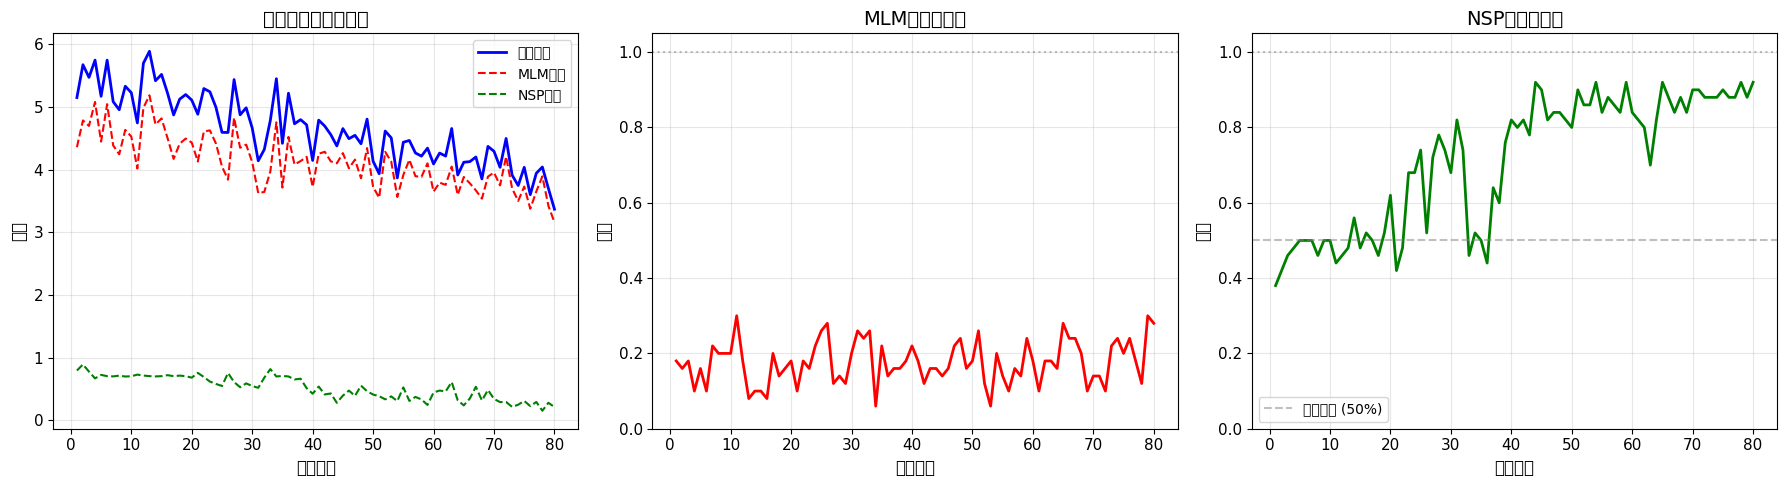

最終エポックの結果:
  合計損失: 3.3672
  MLM損失:  3.1586, 精度: 28.0%
  NSP損失:  0.2086, 精度: 92.0%


In [15]:
# ============================================================
# Section 7 (続き): 学習曲線の可視化
# Plot 2: MLM損失、NSP損失、合計損失の推移
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, num_epochs + 1)

# --- 左: 損失の推移 ---
axes[0].plot(epochs_range, history['total_loss'], 'b-', linewidth=2, label='合計損失')
axes[0].plot(epochs_range, history['mlm_loss'], 'r--', linewidth=1.5, label='MLM損失')
axes[0].plot(epochs_range, history['nsp_loss'], 'g--', linewidth=1.5, label='NSP損失')
axes[0].set_xlabel('エポック', fontsize=12)
axes[0].set_ylabel('損失', fontsize=12)
axes[0].set_title('事前学習の損失推移', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- 中央: MLM精度の推移 ---
axes[1].plot(epochs_range, history['mlm_accuracy'], 'r-', linewidth=2)
axes[1].set_xlabel('エポック', fontsize=12)
axes[1].set_ylabel('精度', fontsize=12)
axes[1].set_title('MLM精度の推移', fontsize=14)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)

# --- 右: NSP精度の推移 ---
axes[2].plot(epochs_range, history['nsp_accuracy'], 'g-', linewidth=2)
axes[2].set_xlabel('エポック', fontsize=12)
axes[2].set_ylabel('精度', fontsize=12)
axes[2].set_title('NSP精度の推移', fontsize=14)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='ランダム (50%)')
axes[2].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"最終エポックの結果:")
print(f"  合計損失: {history['total_loss'][-1]:.4f}")
print(f"  MLM損失:  {history['mlm_loss'][-1]:.4f}, 精度: {history['mlm_accuracy'][-1]:.1%}")
print(f"  NSP損失:  {history['nsp_loss'][-1]:.4f}, 精度: {history['nsp_accuracy'][-1]:.1%}")

---

## 8. 事前学習結果の検証

モデルが実際に有意味な言語表現を学習したかを検証します。

1. **MLM予測の精度**: マスクされた単語を正しく予測できるか
2. **NSP予測の精度**: 文ペアの関係を正しく判定できるか
3. **学習した埋め込みの構造**: t-SNE可視化

In [16]:
# ============================================================
# Section 8: 事前学習結果の検証
# MLM予測のデモンストレーション
# ============================================================

model.eval()

def predict_masked_token(model, sent_a, sent_b, mask_position_in_sent='a',
                        target_word_index=None, top_k=5):
    """
    指定した位置のトークンをマスクして予測する。
    
    Parameters:
    -----------
    model : MiniBERT
    sent_a, sent_b : str
    mask_position_in_sent : 'a' or 'b'
    target_word_index : int
        文中の何番目の単語をマスクするか（0始まり）
    top_k : int
        上位k個の予測を表示
    """
    # BERT形式の入力を構築
    input_ids, token_type_ids, attention_mask = create_bert_input(
        sent_a, sent_b, max_seq_len=max_seq_len
    )
    
    # マスクする位置を決定
    tokens_a = tokenize(sent_a)
    tokens_b = tokenize(sent_b)
    
    if mask_position_in_sent == 'a':
        if target_word_index is None:
            target_word_index = len(tokens_a) // 2
        # [CLS] + tokens_a なので、位置は target_word_index + 1
        mask_pos = target_word_index + 1
        original_word = tokens_a[target_word_index]
    else:
        if target_word_index is None:
            target_word_index = len(tokens_b) // 2
        # [CLS] + tokens_a + [SEP] + tokens_b なので
        mask_pos = len(tokens_a) + 2 + target_word_index
        original_word = tokens_b[target_word_index]
    
    original_id = input_ids[mask_pos]
    
    # マスクを適用
    masked_ids = list(input_ids)
    masked_ids[mask_pos] = MASK_ID
    
    # 推論
    with torch.no_grad():
        input_tensor = torch.tensor([masked_ids], dtype=torch.long).to(device)
        type_tensor = torch.tensor([token_type_ids], dtype=torch.long).to(device)
        mask_tensor = torch.tensor([attention_mask], dtype=torch.long).to(device)
        
        mlm_logits, _, _ = model(input_tensor, type_tensor, mask_tensor)
    
    # マスク位置の予測
    logits_at_mask = mlm_logits[0, mask_pos, :]  # (vocab_size,)
    probs = F.softmax(logits_at_mask, dim=-1)
    top_probs, top_indices = probs.topk(top_k)
    
    print(f"  文A: '{sent_a}'")
    print(f"  文B: '{sent_b}'")
    print(f"  マスク位置: '{original_word}' → [MASK]")
    print(f"  Top-{top_k} 予測:")
    for rank, (prob, idx) in enumerate(zip(top_probs, top_indices)):
        word = id2word[idx.item()]
        marker = " <-- 正解" if idx.item() == original_id else ""
        print(f"    {rank+1}. '{word}' ({prob:.4f}){marker}")
    print()


print("=" * 70)
print("MLM予測のデモンストレーション")
print("=" * 70)
print()

# いくつかの例で予測を実行
test_examples = [
    ("the cat sat on the mat", "it was a warm sunny day", 'a', 1),
    ("the dog ran in the park", "children were playing nearby", 'a', 3),
    ("she went to the store", "she bought some fresh fruit", 'b', 2),
    ("rain started to fall", "people opened their umbrellas", 'a', 0),
    ("he studied hard for the exam", "he passed with a high score", 'b', 0),
]

for sent_a, sent_b, which_sent, word_idx in test_examples:
    predict_masked_token(model, sent_a, sent_b, which_sent, word_idx)

MLM予測のデモンストレーション

  文A: 'the cat sat on the mat'
  文B: 'it was a warm sunny day'
  マスク位置: 'cat' → [MASK]
  Top-5 予測:
    1. 'drove' (0.1215)
    2. 'music' (0.1112)
    3. 'boat' (0.0497)
    4. 'baby' (0.0441)
    5. 'wrote' (0.0435)

  文A: 'the dog ran in the park'
  文B: 'children were playing nearby'
  マスク位置: 'in' → [MASK]
  Top-5 予測:
    1. 'the' (0.3560)
    2. 'at' (0.0549)
    3. 'in' (0.0517) <-- 正解
    4. 'ground' (0.0500)
    5. 'on' (0.0475)

  文A: 'she went to the store'
  文B: 'she bought some fresh fruit'
  マスク位置: 'some' → [MASK]
  Top-5 予測:
    1. 'quickly' (0.0511)
    2. 'and' (0.0306)
    3. 'their' (0.0293)
    4. 'a' (0.0292)
    5. 'score' (0.0253)

  文A: 'rain started to fall'
  文B: 'people opened their umbrellas'
  マスク位置: 'rain' → [MASK]
  Top-5 予測:
    1. 'the' (0.6107)
    2. 'she' (0.1129)
    3. 'he' (0.0877)
    4. 'on' (0.0108)
    5. 'rain' (0.0092) <-- 正解

  文A: 'he studied hard for the exam'
  文B: 'he passed with a high score'
  マスク位置: 'he' → [MASK]
  Top

In [17]:
# ============================================================
# Section 8 (続き): NSP予測の検証
# ============================================================

def predict_nsp(model, sent_a, sent_b):
    """
    2つの文が連続するか（IsNext）を予測する。
    """
    input_ids, token_type_ids, attention_mask = create_bert_input(
        sent_a, sent_b, max_seq_len=max_seq_len
    )
    
    with torch.no_grad():
        input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
        type_tensor = torch.tensor([token_type_ids], dtype=torch.long).to(device)
        mask_tensor = torch.tensor([attention_mask], dtype=torch.long).to(device)
        
        _, nsp_logits, _ = model(input_tensor, type_tensor, mask_tensor)
    
    probs = F.softmax(nsp_logits[0], dim=-1)
    pred = nsp_logits[0].argmax().item()
    
    return pred, probs[1].item()  # 予測ラベル, IsNext確率


print("=" * 70)
print("NSP予測のデモンストレーション")
print("=" * 70)
print()

# 正例のテスト（連続する文ペア）
print("【正例 (IsNext) のテスト】")
print("-" * 50)
correct_pos = 0
total_pos = 0
for sent_a, sent_b in related_pairs[:8]:
    pred, prob = predict_nsp(model, sent_a, sent_b)
    label = "IsNext" if pred == 1 else "NotNext"
    marker = "正解" if pred == 1 else "不正解"
    print(f"  A: '{sent_a}'")
    print(f"  B: '{sent_b}'")
    print(f"  予測: {label} (IsNext確率: {prob:.4f}) [{marker}]")
    print()
    correct_pos += (pred == 1)
    total_pos += 1

# 負例のテスト（ランダムな文ペア）
print("【負例 (NotNext) のテスト】")
print("-" * 50)
correct_neg = 0
total_neg = 0
for i in range(8):
    sent_a = related_pairs[i][0]
    # 異なるペアから文Bを取得
    j = (i + 5) % len(related_pairs)
    sent_b = related_pairs[j][1]
    
    pred, prob = predict_nsp(model, sent_a, sent_b)
    label = "IsNext" if pred == 1 else "NotNext"
    marker = "正解" if pred == 0 else "不正解"
    print(f"  A: '{sent_a}'")
    print(f"  B: '{sent_b}'")
    print(f"  予測: {label} (IsNext確率: {prob:.4f}) [{marker}]")
    print()
    correct_neg += (pred == 0)
    total_neg += 1

print(f"正例の精度: {correct_pos}/{total_pos} = {correct_pos/total_pos:.1%}")
print(f"負例の精度: {correct_neg}/{total_neg} = {correct_neg/total_neg:.1%}")
print(f"全体の精度: {(correct_pos+correct_neg)}/{(total_pos+total_neg)} = {(correct_pos+correct_neg)/(total_pos+total_neg):.1%}")

NSP予測のデモンストレーション

【正例 (IsNext) のテスト】
--------------------------------------------------
  A: 'the cat sat on the mat'
  B: 'it was a warm sunny day'
  予測: IsNext (IsNext確率: 0.9800) [正解]

  A: 'the dog ran in the park'
  B: 'children were playing nearby'
  予測: IsNext (IsNext確率: 0.9720) [正解]

  A: 'she went to the store'
  B: 'she bought some fresh fruit'
  予測: IsNext (IsNext確率: 0.9678) [正解]

  A: 'he opened the book'
  B: 'the story was very interesting'
  予測: IsNext (IsNext確率: 0.9607) [正解]

  A: 'the sun rose in the east'
  B: 'the sky turned bright orange'
  予測: IsNext (IsNext確率: 0.9719) [正解]

  A: 'the teacher entered the room'
  B: 'students sat at their desks'
  予測: IsNext (IsNext確率: 0.9349) [正解]

  A: 'rain started to fall'
  B: 'people opened their umbrellas'
  予測: IsNext (IsNext確率: 0.9446) [正解]

  A: 'the bird flew over the tree'
  B: 'it landed on a branch'
  予測: IsNext (IsNext確率: 0.9371) [正解]

【負例 (NotNext) のテスト】
--------------------------------------------------
  A: 'the cat

findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' n

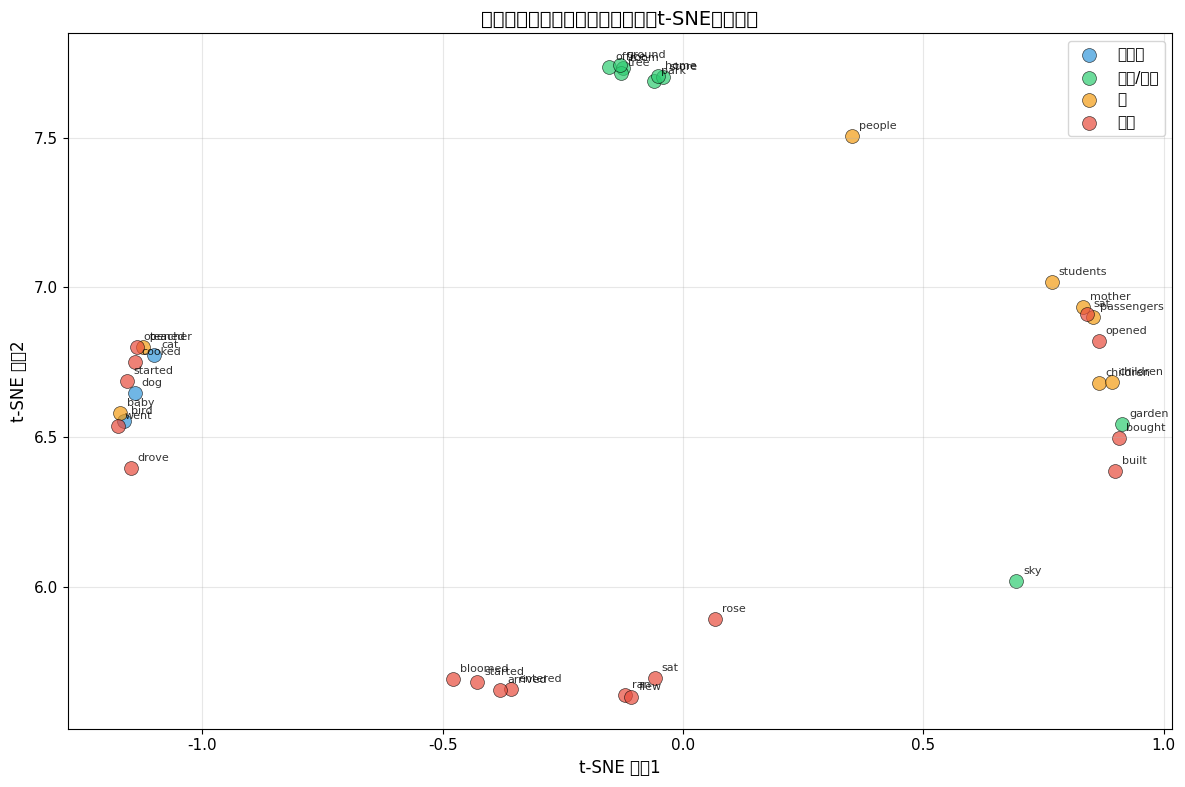

カテゴリごとのトークン数:
  生き物: 3個
  場所/自然: 9個
  人: 8個
  動詞: 17個

同じカテゴリの単語が近くに配置されていれば、
モデルが意味的な関係を学習していることを示唆します。


In [18]:
# ============================================================
# Section 8 (続き): 学習した埋め込みのt-SNE可視化
# Plot 3: トークン埋め込みの2D空間での配置
# ============================================================

from sklearn.manifold import TSNE

# 全文を通してモデルの隠れ状態を取得
all_embeddings = []
all_words = []
all_categories = []  # 単語のカテゴリ（可視化用）

# カテゴリ定義
word_categories = {
    # 動作・動詞
    'sat': '動詞', 'ran': '動詞', 'went': '動詞', 'opened': '動詞',
    'rose': '動詞', 'entered': '動詞', 'started': '動詞', 'flew': '動詞',
    'cooked': '動詞', 'drove': '動詞', 'arrived': '動詞', 'played': '動詞',
    'painted': '動詞', 'swam': '動詞', 'wrote': '動詞', 'sailed': '動詞',
    'read': '動詞', 'prepared': '動詞', 'bloomed': '動詞', 'built': '動詞',
    'bought': '動詞', 'passed': '動詞', 'studied': '動詞',
    # 自然・場所
    'park': '場所/自然', 'store': '場所/自然', 'garden': '場所/自然',
    'sky': '場所/自然', 'lake': '場所/自然', 'pond': '場所/自然',
    'ground': '場所/自然', 'tree': '場所/自然', 'room': '場所/自然',
    'office': '場所/自然', 'home': '場所/自然',
    # 人・生き物
    'cat': '生き物', 'dog': '生き物', 'bird': '生き物', 'fish': '生き物',
    'baby': '人', 'mother': '人', 'teacher': '人', 'children': '人',
    'chef': '人', 'students': '人', 'people': '人', 'guests': '人',
    'passengers': '人', 'audience': '人',
}

model.eval()

for sent_a, sent_b in related_pairs[:15]:
    input_ids, token_type_ids, attention_mask = create_bert_input(
        sent_a, sent_b, max_seq_len=max_seq_len
    )
    
    with torch.no_grad():
        input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
        type_tensor = torch.tensor([token_type_ids], dtype=torch.long).to(device)
        mask_tensor = torch.tensor([attention_mask], dtype=torch.long).to(device)
        
        _, _, hidden_states = model(input_tensor, type_tensor, mask_tensor)
    
    # 各トークンの埋め込みを収集
    tokens = decode_ids(input_ids)
    for i, (token, mask) in enumerate(zip(tokens, attention_mask)):
        if mask == 1 and token not in ['[PAD]', '[CLS]', '[SEP]', '[MASK]']:
            emb = hidden_states[0, i, :].cpu().numpy()
            if token in word_categories:
                all_embeddings.append(emb)
                all_words.append(token)
                all_categories.append(word_categories[token])

# t-SNEで2次元に射影
if len(all_embeddings) > 5:
    embeddings_array = np.array(all_embeddings)
    
    perplexity_val = min(30, len(embeddings_array) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=max(5, perplexity_val))
    embeddings_2d = tsne.fit_transform(embeddings_array)
    
    # カテゴリごとに色分けしてプロット
    fig, ax = plt.subplots(figsize=(12, 8))
    
    unique_categories = list(set(all_categories))
    colors_map = {'動詞': '#e74c3c', '場所/自然': '#2ecc71', '生き物': '#3498db', '人': '#f39c12'}
    
    for cat in unique_categories:
        mask = [c == cat for c in all_categories]
        points = embeddings_2d[mask]
        words = [w for w, m in zip(all_words, mask) if m]
        
        color = colors_map.get(cat, '#95a5a6')
        ax.scatter(points[:, 0], points[:, 1], c=color, s=100,
                  label=cat, edgecolors='black', linewidths=0.5, alpha=0.7)
        
        # 単語ラベルを追加
        for j, word in enumerate(words):
            ax.annotate(word, (points[j, 0], points[j, 1]),
                       textcoords="offset points", xytext=(5, 5),
                       fontsize=8, alpha=0.8)
    
    ax.set_title('事前学習後のトークン埋め込み（t-SNE可視化）', fontsize=14)
    ax.set_xlabel('t-SNE 次元1', fontsize=12)
    ax.set_ylabel('t-SNE 次元2', fontsize=12)
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("カテゴリごとのトークン数:")
    for cat in unique_categories:
        count = all_categories.count(cat)
        print(f"  {cat}: {count}個")
    print()
    print("同じカテゴリの単語が近くに配置されていれば、")
    print("モデルが意味的な関係を学習していることを示唆します。")
else:
    print("埋め込みデータが不足しています。")

---

## 9. ファインチューニング: テキスト分類

事前学習したミニBERTを、下流タスク（感情分析的な分類タスク）に  
ファインチューニングします。

### ファインチューニングの流れ

```
事前学習済みMiniBERT
        ↓
[CLS]トークンの出力 → 分類ヘッド（Linear → Softmax）
        ↓
全パラメータを微調整（学習率は小さめ）
```

In [19]:
# ============================================================
# Section 9: ファインチューニング用の分類タスク
# 簡易的な感情分析タスクを構築
# ============================================================

# 感情分析データ（ポジティブ/ネガティブ）
# 訓練用コーパスの語彙に含まれる単語を使用
sentiment_data = [
    # (文, ラベル) - 1=ポジティブ, 0=ネガティブ
    # ポジティブ
    ("the food smelled delicious", 1),
    ("the garden looked beautiful", 1),
    ("the colors were bright and vivid", 1),
    ("everyone felt relaxed and happy", 1),
    ("the sunset was breathtaking", 1),
    ("the story was very interesting", 1),
    ("the water was clear and calm", 1),
    ("the sky turned bright orange", 1),
    ("he passed with a high score", 1),
    ("the audience enjoyed the show", 1),
    ("the lamp provided soft light", 1),
    ("the music played softly", 1),
    # ネガティブ
    ("the traffic was very heavy", 0),
    ("the baby started crying", 0),
    ("rain started to fall", 0),
    ("the wind blew strongly", 0),
    ("the leaves fell from the trees", 0),
    ("snow covered the ground", 0),
    ("the phone rang loudly", 0),
    ("he drove to the office", 0),
    ("the train arrived on time", 0),
    ("people opened their umbrellas", 0),
    ("she answered it immediately", 0),
    ("students sat at their desks", 0),
]

random.shuffle(sentiment_data)

print(f"感情分析データセット: {len(sentiment_data)}件")
print(f"  ポジティブ: {sum(1 for _, l in sentiment_data if l == 1)}件")
print(f"  ネガティブ: {sum(1 for _, l in sentiment_data if l == 0)}件")
print()
print("例:")
for sent, label in sentiment_data[:4]:
    sentiment = "ポジティブ" if label == 1 else "ネガティブ"
    print(f"  '{sent}' -> {sentiment}")

感情分析データセット: 24件
  ポジティブ: 12件
  ネガティブ: 12件

例:
  'the music played softly' -> ポジティブ
  'the garden looked beautiful' -> ポジティブ
  'the audience enjoyed the show' -> ポジティブ
  'the colors were bright and vivid' -> ポジティブ


In [20]:
# ============================================================
# Section 9 (続き): ファインチューニング用モデルの構築
# 事前学習済みMiniBERTに分類ヘッドを追加
# ============================================================

class BERTForClassification(nn.Module):
    """
    事前学習済みMiniBERTに分類ヘッドを追加したモデル。
    [CLS]トークンの出力を使って分類を行う。
    """
    def __init__(self, pretrained_bert, num_classes=2):
        super().__init__()
        # 事前学習済みBERTのエンコーダ部分を流用
        self.bert = pretrained_bert
        d_model = pretrained_bert.config.d_model
        
        # 分類ヘッド（新規追加）
        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(d_model, num_classes),
        )
    
    def forward(self, input_ids, token_type_ids, attention_mask):
        # BERTの出力を取得
        _, _, hidden_states = self.bert(input_ids, token_type_ids, attention_mask)
        
        # [CLS]トークン（位置0）の出力を使用
        cls_output = hidden_states[:, 0, :]  # (batch, d_model)
        
        # 分類
        logits = self.classifier(cls_output)  # (batch, num_classes)
        return logits


# ファインチューニング用データセット
class SentimentDataset(Dataset):
    def __init__(self, data, word2id, max_seq_len=32):
        self.data = data
        self.word2id = word2id
        self.max_seq_len = max_seq_len
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sentence, label = self.data[idx]
        # 分類タスクなので文Bは空文字列として扱う
        # [CLS] sentence [SEP] のみ
        input_ids = [CLS_ID] + encode_sentence(sentence) + [SEP_ID]
        token_type_ids = [0] * len(input_ids)
        attention_mask = [1] * len(input_ids)
        
        # パディング
        pad_len = self.max_seq_len - len(input_ids)
        if pad_len > 0:
            input_ids += [PAD_ID] * pad_len
            token_type_ids += [0] * pad_len
            attention_mask += [0] * pad_len
        else:
            input_ids = input_ids[:self.max_seq_len]
            token_type_ids = token_type_ids[:self.max_seq_len]
            attention_mask = attention_mask[:self.max_seq_len]
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long),
        }


# モデルの初期化
# 事前学習済みのBERTを使う場合
ft_model_pretrained = BERTForClassification(model, num_classes=2).to(device)

# 比較用: 事前学習なし（ランダム初期化）のBERTを使う場合
random_bert = MiniBERT(config).to(device)
ft_model_random = BERTForClassification(random_bert, num_classes=2).to(device)

print("ファインチューニング用モデルを構築しました")
print(f"  事前学習済みBERT + 分類ヘッド")
print(f"  比較用: ランダム初期化BERT + 分類ヘッド")

ファインチューニング用モデルを構築しました
  事前学習済みBERT + 分類ヘッド
  比較用: ランダム初期化BERT + 分類ヘッド


In [21]:
# ============================================================
# Section 9 (続き): ファインチューニングの実行
# 事前学習済み vs ランダム初期化 の比較
# ============================================================

def finetune_model(ft_model, train_data, num_epochs=50, lr=5e-4):
    """
    分類モデルをファインチューニングする。
    """
    dataset = SentimentDataset(train_data, word2id, max_seq_len=max_seq_len)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)
    
    optimizer = optim.AdamW(ft_model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []
    acc_history = []
    
    for epoch in range(num_epochs):
        ft_model.train()
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0
        
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = ft_model(input_ids, token_type_ids, attention_mask)
            loss = criterion(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ft_model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            preds = logits.argmax(dim=-1)
            epoch_correct += (preds == labels).sum().item()
            epoch_total += labels.size(0)
        
        avg_loss = epoch_loss / len(loader)
        accuracy = epoch_correct / epoch_total
        loss_history.append(avg_loss)
        acc_history.append(accuracy)
    
    return loss_history, acc_history


# ファインチューニングの実行
print("=" * 70)
print("ファインチューニングの実行")
print("=" * 70)
print()

ft_epochs = 50

print("[1/2] 事前学習済みBERTのファインチューニング...")
loss_pretrained, acc_pretrained = finetune_model(
    ft_model_pretrained, sentiment_data, num_epochs=ft_epochs, lr=5e-4
)
print(f"  最終精度: {acc_pretrained[-1]:.1%}")

print("[2/2] ランダム初期化BERTのファインチューニング...")
loss_random, acc_random = finetune_model(
    ft_model_random, sentiment_data, num_epochs=ft_epochs, lr=5e-4
)
print(f"  最終精度: {acc_random[-1]:.1%}")
print()
print("ファインチューニングが完了しました")

ファインチューニングの実行

[1/2] 事前学習済みBERTのファインチューニング...
  最終精度: 100.0%
[2/2] ランダム初期化BERTのファインチューニング...
  最終精度: 100.0%

ファインチューニングが完了しました


findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' n

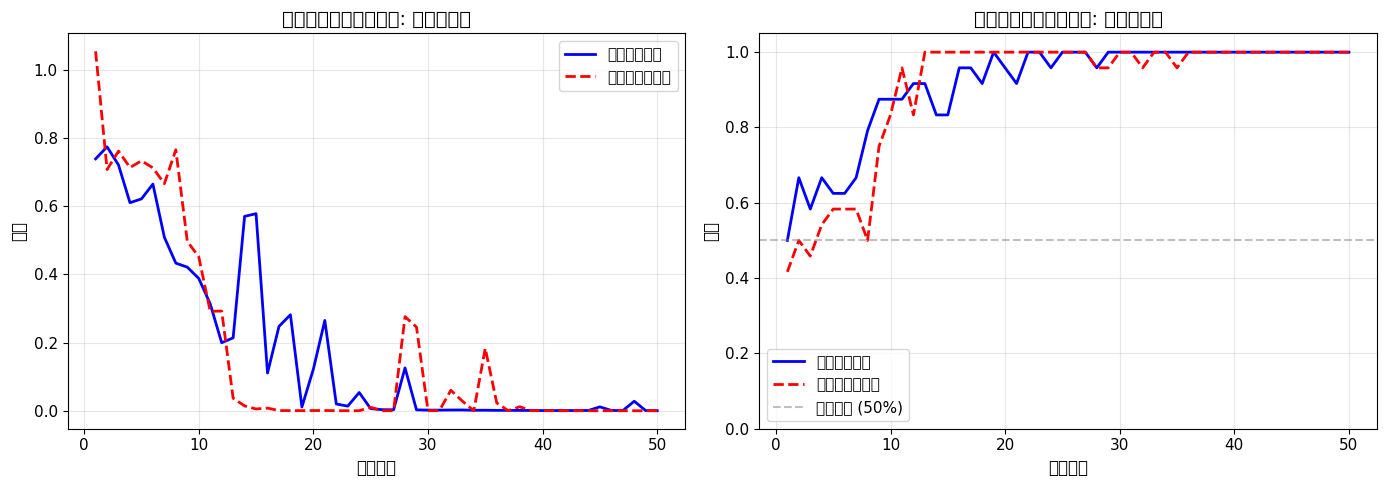

分析結果:
  事前学習済み — 最終精度: 100.0%, 最終損失: 0.0005
  ランダム初期化 — 最終精度: 100.0%, 最終損失: 0.0003

事前学習済みモデルの方が:
  - より速く収束する傾向があります（学習曲線の立ち上がり）
  - より高い精度に到達する可能性があります
  - 特にデータが少ない場合に、事前学習の恩恵が大きくなります


In [22]:
# ============================================================
# Section 9 (続き): ファインチューニング結果の可視化
# Plot 4: 事前学習済み vs ランダム初期化 の比較
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ft_epochs_range = range(1, ft_epochs + 1)

# --- 左: 損失の比較 ---
axes[0].plot(ft_epochs_range, loss_pretrained, 'b-', linewidth=2,
            label='事前学習済み')
axes[0].plot(ft_epochs_range, loss_random, 'r--', linewidth=2,
            label='ランダム初期化')
axes[0].set_xlabel('エポック', fontsize=12)
axes[0].set_ylabel('損失', fontsize=12)
axes[0].set_title('ファインチューニング: 損失の比較', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- 右: 精度の比較 ---
axes[1].plot(ft_epochs_range, acc_pretrained, 'b-', linewidth=2,
            label='事前学習済み')
axes[1].plot(ft_epochs_range, acc_random, 'r--', linewidth=2,
            label='ランダム初期化')
axes[1].set_xlabel('エポック', fontsize=12)
axes[1].set_ylabel('精度', fontsize=12)
axes[1].set_title('ファインチューニング: 精度の比較', fontsize=14)
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='ランダム (50%)')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("分析結果:")
print(f"  事前学習済み — 最終精度: {acc_pretrained[-1]:.1%}, 最終損失: {loss_pretrained[-1]:.4f}")
print(f"  ランダム初期化 — 最終精度: {acc_random[-1]:.1%}, 最終損失: {loss_random[-1]:.4f}")
print()
print("事前学習済みモデルの方が:")
print("  - より速く収束する傾向があります（学習曲線の立ち上がり）")
print("  - より高い精度に到達する可能性があります")
print("  - 特にデータが少ない場合に、事前学習の恩恵が大きくなります")

findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Arial Unicode MS' n

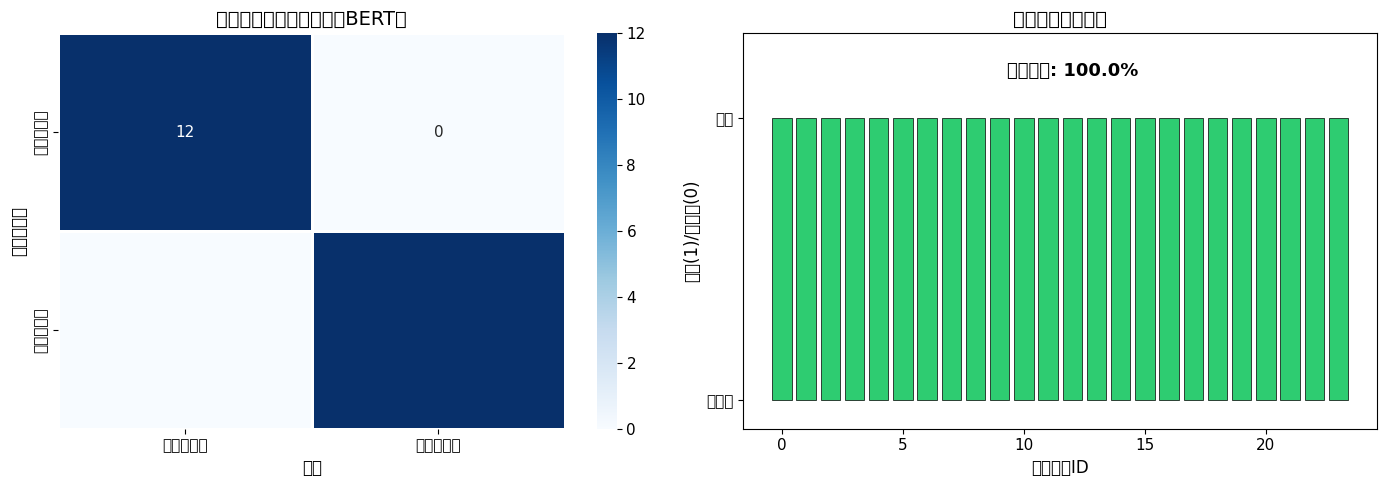

分類精度: 100.0% (24/24)


In [23]:
# ============================================================
# Section 9 (続き): ファインチューニング結果の詳細分析
# Plot 5: 分類結果の可視化
# ============================================================

# 全データに対する予測を取得
ft_model_pretrained.eval()

predictions = []
true_labels = []
sentences_list = []

for sent, label in sentiment_data:
    input_ids = [CLS_ID] + encode_sentence(sent) + [SEP_ID]
    token_type_ids = [0] * len(input_ids)
    attention_mask = [1] * len(input_ids)
    
    pad_len = max_seq_len - len(input_ids)
    if pad_len > 0:
        input_ids += [PAD_ID] * pad_len
        token_type_ids += [0] * pad_len
        attention_mask += [0] * pad_len
    
    with torch.no_grad():
        input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
        type_tensor = torch.tensor([token_type_ids], dtype=torch.long).to(device)
        mask_tensor = torch.tensor([attention_mask], dtype=torch.long).to(device)
        
        logits = ft_model_pretrained(input_tensor, type_tensor, mask_tensor)
        pred = logits.argmax(dim=-1).item()
    
    predictions.append(pred)
    true_labels.append(label)
    sentences_list.append(sent)

# 混同行列の計算
from collections import defaultdict
cm = np.zeros((2, 2), dtype=int)
for true, pred in zip(true_labels, predictions):
    cm[true][pred] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左: 混同行列 ---
sns.heatmap(cm, ax=axes[0], annot=True, fmt='d', cmap='Blues',
           xticklabels=['ネガティブ', 'ポジティブ'],
           yticklabels=['ネガティブ', 'ポジティブ'],
           linewidths=1)
axes[0].set_xlabel('予測', fontsize=12)
axes[0].set_ylabel('真のラベル', fontsize=12)
axes[0].set_title('混同行列（事前学習済みBERT）', fontsize=14)

# --- 右: 各サンプルの予測結果 ---
correct = [1 if p == t else 0 for p, t in zip(predictions, true_labels)]
axes[1].bar(range(len(correct)), correct,
           color=['#2ecc71' if c else '#e74c3c' for c in correct],
           edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('サンプルID', fontsize=12)
axes[1].set_ylabel('正解(1)/不正解(0)', fontsize=12)
axes[1].set_title('各サンプルの正誤', fontsize=14)
axes[1].set_ylim(-0.1, 1.3)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['不正解', '正解'])
accuracy = sum(correct) / len(correct)
axes[1].text(len(correct)/2, 1.15, f'全体精度: {accuracy:.1%}',
            ha='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"分類精度: {accuracy:.1%} ({sum(correct)}/{len(correct)})")

---

## 10. まとめ・チートシート・よくある間違い・自己評価クイズ

In [24]:
# ============================================================
# Section 10: まとめ
# 事前学習 vs ファインチューニングの比較表
# ============================================================

print("=" * 70)
print("まとめ: BERTの事前学習メカニズム")
print("=" * 70)
print()
print(f"{'項目':<30} {'事前学習':<25} {'ファインチューニング'}")
print("-" * 75)
print(f"{'データ':<30} {'大量のラベルなしテキスト':<25} {'少量のラベル付きデータ'}")
print(f"{'目的関数':<30} {'MLM + NSP':<25} {'タスク固有の損失関数'}")
print(f"{'学習率':<30} {'比較的大きい':<25} {'小さい（2e-5 ~ 5e-5）'}")
print(f"{'エポック数':<30} {'長い（40エポック）':<25} {'短い（3-5エポック）'}")
print(f"{'パラメータ更新':<30} {'全パラメータ':<25} {'全パラメータ（微調整）'}")
print(f"{'目標':<30} {'汎用的な言語理解':<25} {'タスク特化の性能'}")
print(f"{'コスト':<30} {'非常に高い':<25} {'比較的低い'}")
print()
print("=" * 70)
print("チートシート: BERT事前学習の構成要素")
print("=" * 70)
print()
print("【MLM (Masked Language Modeling)】")
print("  - 入力の15%をランダムにマスク")
print("  - 80%: [MASK]に置換")
print("  - 10%: ランダムな単語に置換")
print("  - 10%: そのまま（変更なし）")
print("  - 目的: 双方向の文脈理解を学習")
print()
print("【NSP (Next Sentence Prediction)】")
print("  - 50%: 実際に連続する文ペア (IsNext)")
print("  - 50%: ランダムな文ペア (NotNext)")
print("  - [CLS]トークンの出力で判定")
print("  - 目的: 文間の関係性理解を学習")
print()
print("【入力形式】")
print("  [CLS] 文A [SEP] 文B [SEP]")
print("  Token Embedding + Position Embedding + Segment Embedding")

まとめ: BERTの事前学習メカニズム

項目                             事前学習                      ファインチューニング
---------------------------------------------------------------------------
データ                            大量のラベルなしテキスト              少量のラベル付きデータ
目的関数                           MLM + NSP                 タスク固有の損失関数
学習率                            比較的大きい                    小さい（2e-5 ~ 5e-5）
エポック数                          長い（40エポック）                短い（3-5エポック）
パラメータ更新                        全パラメータ                    全パラメータ（微調整）
目標                             汎用的な言語理解                  タスク特化の性能
コスト                            非常に高い                     比較的低い

チートシート: BERT事前学習の構成要素

【MLM (Masked Language Modeling)】
  - 入力の15%をランダムにマスク
  - 80%: [MASK]に置換
  - 10%: ランダムな単語に置換
  - 10%: そのまま（変更なし）
  - 目的: 双方向の文脈理解を学習

【NSP (Next Sentence Prediction)】
  - 50%: 実際に連続する文ペア (IsNext)
  - 50%: ランダムな文ペア (NotNext)
  - [CLS]トークンの出力で判定
  - 目的: 文間の関係性理解を学習

【入力形式】
  [CLS] 文A [SEP] 文B [SEP]
  Token Embedding + Position Embeddi

In [25]:
# ============================================================
# よくある間違い
# ============================================================

print("=" * 70)
print("よくある間違い")
print("=" * 70)
print()

print("【間違い1】MLMのマスク率を高くしすぎる")
print("-" * 50)
print("  × 30%や50%のトークンをマスクする")
print("  ○ 15%に抑える（高すぎると文脈情報が不足し、学習が困難になる）")
print("  理由: マスクが多すぎると、予測に必要な周囲の文脈が失われます。")
print("        15%は十分な学習シグナルと文脈情報のバランス点です。")
print()

print("【間違い2】ファインチューニング時に学習率が高すぎる")
print("-" * 50)
print("  × 事前学習と同じ学習率（1e-3等）でファインチューニング")
print("  ○ 小さい学習率（2e-5 ~ 5e-5）を使用")
print("  理由: 事前学習で獲得した知識を破壊しないよう、")
print("        パラメータの変更を最小限にする必要があります。")
print("        これを 'catastrophic forgetting' の回避と呼びます。")
print()

print("【間違い3】NSPの正例/負例の比率が偏っている")
print("-" * 50)
print("  × 正例90%、負例10% のような偏った比率")
print("  ○ 正例50%、負例50% のバランスの取れた比率")
print("  理由: 偏った比率では、モデルが多数派クラスを常に予測するだけで")
print("        高い精度を達成してしまい、有意義な学習が行われません。")

よくある間違い

【間違い1】MLMのマスク率を高くしすぎる
--------------------------------------------------
  × 30%や50%のトークンをマスクする
  ○ 15%に抑える（高すぎると文脈情報が不足し、学習が困難になる）
  理由: マスクが多すぎると、予測に必要な周囲の文脈が失われます。
        15%は十分な学習シグナルと文脈情報のバランス点です。

【間違い2】ファインチューニング時に学習率が高すぎる
--------------------------------------------------
  × 事前学習と同じ学習率（1e-3等）でファインチューニング
  ○ 小さい学習率（2e-5 ~ 5e-5）を使用
  理由: 事前学習で獲得した知識を破壊しないよう、
        パラメータの変更を最小限にする必要があります。
        これを 'catastrophic forgetting' の回避と呼びます。

【間違い3】NSPの正例/負例の比率が偏っている
--------------------------------------------------
  × 正例90%、負例10% のような偏った比率
  ○ 正例50%、負例50% のバランスの取れた比率
  理由: 偏った比率では、モデルが多数派クラスを常に予測するだけで
        高い精度を達成してしまい、有意義な学習が行われません。


### 自己評価クイズ

以下の問題で理解度をチェックしましょう。

---

**Q1**: BERTのMLMにおける80/10/10ルールの目的は何ですか？なぜ100%を[MASK]にしないのですか？

<details>
<summary>回答を見る</summary>

100%を[MASK]にすると、以下の問題が発生します:

- **ファインチューニング時との不一致**: ファインチューニング時には[MASK]トークンが入力に現れないため、事前学習とファインチューニングの入力分布にギャップが生じます
- **10%ランダム置換**: モデルに「どの位置でも正しい表現を維持する」ことを強制し、[MASK]以外の位置でも予測能力を持たせます
- **10%そのまま**: モデルが実際の入力トークンに対しても正しい表現を出力するよう促します

この設計により、事前学習とファインチューニングのギャップを軽減しています。
</details>

---

**Q2**: BERTの事前学習で、MLM損失とNSP損失はどのように組み合わされますか？

<details>
<summary>回答を見る</summary>

**合計損失 = MLM損失 + NSP損失** として単純に加算されます。

- **MLM損失**: マスクされた位置でのクロスエントロピー損失。語彙サイズ上の確率分布から正解トークンの負の対数尤度を計算します。マスクされていない位置は損失計算から除外されます（ignore_index=-100）。

- **NSP損失**: [CLS]トークンの出力に基づく二値分類のクロスエントロピー損失。IsNext(1) か NotNext(0) かを予測します。

両損失は同じ重みで加算され、同時に最適化されます。
</details>

---

**Q3**: BERTの入力が `[CLS] 文A [SEP] 文B [SEP]` の形式である理由を説明してください。各特殊トークンの役割は？

<details>
<summary>回答を見る</summary>

- **[CLS]**: Classification トークン。最終層での出力が文全体の要約表現として使われます。NSP判定や下流タスクの分類に使用されます。

- **[SEP]**: Separator トークン。2つの文の境界を明示的に示します。Segment Embedding と組み合わせて、モデルが文Aと文Bを区別できるようにします。

この形式により、BERTは:
1. 単一文タスク（[CLS] 文 [SEP]）
2. 文ペアタスク（[CLS] 文A [SEP] 文B [SEP]）
の両方に対応できる統一的な入力形式を実現しています。
</details>

---

**Q4**: 事前学習とファインチューニングで学習率を変えるべき理由は何ですか？

<details>
<summary>回答を見る</summary>

- **事前学習**: パラメータはランダムに初期化されているため、比較的大きな学習率（例: 1e-4）で大きなステップを取り、言語の汎用的な知識を素早く学習する必要があります。

- **ファインチューニング**: パラメータは既に有用な言語知識を保持しているため、小さな学習率（例: 2e-5 ~ 5e-5）で微調整する必要があります。大きな学習率を使うと、事前学習で獲得した知識が破壊される「壊滅的忘却（catastrophic forgetting）」が発生します。

つまり、事前学習済みの知識を「壊さずに活かしながら」タスクに適応させるために、学習率を小さくします。
</details>

---

**Q5**: 後続の研究（RoBERTa等）でNSPが不要とされた理由は何だと考えられますか？

<details>
<summary>回答を見る</summary>

RoBERTa (Liu et al., 2019) は、NSPを除外しても性能が向上することを示しました。考えられる理由:

1. **NSPタスクが簡単すぎる**: ランダムに選んだ文ペアはトピックが明らかに異なるため、単語の重なりだけで判別できてしまい、深い文間理解の学習に繋がらない

2. **MLMだけで十分**: MLMが強力な双方向文脈表現を学習するため、NSPの追加効果が限定的

3. **より良い代替手法**: ALBERT は Sentence Order Prediction (SOP) という、より難しいタスク（文の順序が正しいか逆か）を提案し、より効果的であることを示しました

ただし、BERTの設計意図（文間関係の理解）自体は重要であり、より効果的な方法が模索されています。
</details>

In [26]:
# ============================================================
# 次のステップ
# ============================================================

print("=" * 70)
print("Notebook 163 完了!")
print("=" * 70)
print()
print("【学んだこと】")
print("  1. BERTの事前学習は MLM + NSP の2つの目的関数で行われる")
print("  2. MLMの15%マスク戦略と80/10/10ルールの設計意図")
print("  3. NSPによる文間関係の学習メカニズム")
print("  4. ミニBERTをスクラッチから構築・訓練する方法")
print("  5. 事前学習済みモデルのファインチューニング手順")
print("  6. 事前学習の有無による下流タスク性能への影響")
print()
print("【Notebook 152 との対比】")
print("  152: 学習済みBERTの推論と分析（埋め込みの性質）")
print("  163: BERTの訓練メカニズム（MLM/NSP実装、学習ループ）")
print()
print("【参考文献】")
print("  - Devlin et al. (2019). BERT: Pre-training of Deep Bidirectional")
print("    Transformers for Language Understanding. NAACL-HLT.")
print("  - Liu et al. (2019). RoBERTa: A Robustly Optimized BERT")
print("    Pretraining Approach. arXiv.")
print("  - Lan et al. (2020). ALBERT: A Lite BERT for Self-supervised")
print("    Learning of Language Representations. ICLR.")

Notebook 163 完了!

【学んだこと】
  1. BERTの事前学習は MLM + NSP の2つの目的関数で行われる
  2. MLMの15%マスク戦略と80/10/10ルールの設計意図
  3. NSPによる文間関係の学習メカニズム
  4. ミニBERTをスクラッチから構築・訓練する方法
  5. 事前学習済みモデルのファインチューニング手順
  6. 事前学習の有無による下流タスク性能への影響

【Notebook 152 との対比】
  152: 学習済みBERTの推論と分析（埋め込みの性質）
  163: BERTの訓練メカニズム（MLM/NSP実装、学習ループ）

【参考文献】
  - Devlin et al. (2019). BERT: Pre-training of Deep Bidirectional
    Transformers for Language Understanding. NAACL-HLT.
  - Liu et al. (2019). RoBERTa: A Robustly Optimized BERT
    Pretraining Approach. arXiv.
  - Lan et al. (2020). ALBERT: A Lite BERT for Self-supervised
    Learning of Language Representations. ICLR.
